In [2]:
import pandas as pd

df = pd.read_json("../data/support_tickets.json")
df.head()

,ticket_id,created_at,updated_at,customer_id,customer_tier,organization_id,product,product_version,product_module,category,...,response_count,attachments_count,contains_error_code,contains_stack_trace,business_impact,affected_users,weekend_ticket,after_hours,language,region
0,TK-2024-000001,2023-11-02 12:30:10+00:00,2023-11-02 15:30:46+00:00,CUST-02387,starter,ORG-234,CloudBackup Enterprise,4.5.10,encryption_layer,Feature Request,...,9,4,False,False,high,222,False,False,de,APAC
1,TK-2024-000002,2023-02-10 16:31:31+00:00,2023-02-12 09:59:43+00:00,CUST-03724,free,ORG-435,DataSync Pro,4.1.11,data_validator,Account Management,...,4,0,True,False,medium,18,False,False,ja,MEA
2,TK-2024-000003,2024-09-30 07:43:47+00:00,2024-09-30 11:58:47+00:00,CUST-00600,enterprise,ORG-208,API Gateway,3.1.4,request_router,Feature Request,...,4,5,True,True,medium,591,False,True,ja,NA
3,TK-2024-000004,2024-11-27 18:17:26+00:00,2024-11-30 22:07:50+00:00,CUST-04795,starter,ORG-231,CloudBackup Enterprise,3.4.15,backup_service,Account Management,...,10,4,True,True,critical,34,False,True,en,LATAM
4,TK-2024-000005,2024-03-09 15:41:02+00:00,2024-03-10 10:53:38+00:00,CUST-01101,starter,ORG-241,StreamProcessor,2.8.8,monitoring,Feature Request,...,6,3,True,False,medium,325,True,False,de,MEA


In [5]:
# Preprocess
import sys
sys.path.append("../src")  # adds the src folder to Python's search path

from preprocessing import preprocess

X, y, feature_encoders, target_encoders = preprocess(df)

✅ Preprocessing complete
   Features shape : (110000, 61)
   Targets shape  : (110000, 2)
   Feature columns: ['product', 'product_version', 'product_module', 'priority', 'severity', 'customer_sentiment', 'previous_tickets', 'account_age_days', 'account_monthly_value', 'similar_issues_last_30_days', 'product_version_age_days', 'known_issue', 'ticket_text_length', 'attachments_count', 'contains_error_code', 'contains_stack_trace', 'business_impact', 'affected_users', 'weekend_ticket', 'after_hours', 'customer_tier_enterprise', 'customer_tier_free', 'customer_tier_premium', 'customer_tier_professional', 'customer_tier_starter', 'channel_api', 'channel_chat', 'channel_email', 'channel_phone', 'channel_portal', 'channel_slack', 'environment_development', 'environment_production', 'environment_sandbox', 'environment_staging', 'environment_test', 'language_de', 'language_en', 'language_es', 'language_fr', 'language_it', 'language_ja', 'language_pt', 'language_zh', 'region_APAC', 'region_EU',

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# ── assumes you have already run the preprocessing pipeline ──
# X, y, feature_encoders, target_encoders = preprocess(df)

# ============================================================
# CLASS IMBALANCE ANALYSIS
# ============================================================
# y contains the ENCODED targets (integers).
# We use target_encoders to convert them back to readable labels
# so the charts are human-friendly instead of showing 0, 1, 2...
# ============================================================

def plot_class_distribution(y, target_encoders):

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for ax, col in zip(axes, ["category", "subcategory"]):

        # --- decode integers back to original string labels ---
        # target_encoders[col].classes_ is an array like:
        # ["Bug", "Feature Request", "Question", ...]
        # where index 0 = "Bug", index 1 = "Feature Request", etc.
        # So we map each integer in y[col] back to its string
        decoded = y[col].map(lambda i: target_encoders[col].classes_[i])

        # --- count how many tickets fall into each class ---
        counts = decoded.value_counts().sort_values(ascending=False)

        # --- compute percentage share of each class ---
        percentages = (counts / counts.sum() * 100).round(1)

        # --- plot a bar chart ---
        bars = ax.bar(counts.index, counts.values, color="steelblue", edgecolor="white")
        ax.set_title(f"Class distribution  {col}", fontsize=13)
        ax.set_xlabel("Class")
        ax.set_ylabel("Number of tickets")
        ax.tick_params(axis="x", rotation=45)

        # --- annotate each bar with count and percentage ---
        for bar, pct in zip(bars, percentages):
            ax.text(
                bar.get_x() + bar.get_width() / 2,  # center of bar
                bar.get_height() + 0.5,              # just above bar
                f"{int(bar.get_height())} ({pct}%)", # e.g. "320 (45.2%)"
                ha="center", va="bottom", fontsize=9
            )

    plt.tight_layout()
    plt.show()

    # ── also print a summary table in text form ──
    print("\n📊 IMBALANCE SUMMARY\n")
    for col in ["category", "subcategory"]:
        decoded = y[col].map(lambda i: target_encoders[col].classes_[i])
        counts = decoded.value_counts()
        percentages = (counts / counts.sum() * 100).round(1)

        print(f"  {col.upper()}")
        for label, cnt, pct in zip(counts.index, counts.values, percentages.values):
            bar = "█" * int(pct // 2)  # simple ascii bar proportional to %
            print(f"    {label:<25} {cnt:>5} tickets  {pct:>5}%  {bar}")

        # imbalance ratio = largest class / smallest class
        # a ratio > 5 is generally considered problematic
        ratio = counts.max() / counts.min()
        print(f"\n    ⚠️  Imbalance ratio: {ratio:.1f}x  (largest / smallest class)")
        print(f"    {'🔴 High imbalance  consider resampling or class weights' if ratio > 5 else '🟢 Imbalance looks manageable'}\n")




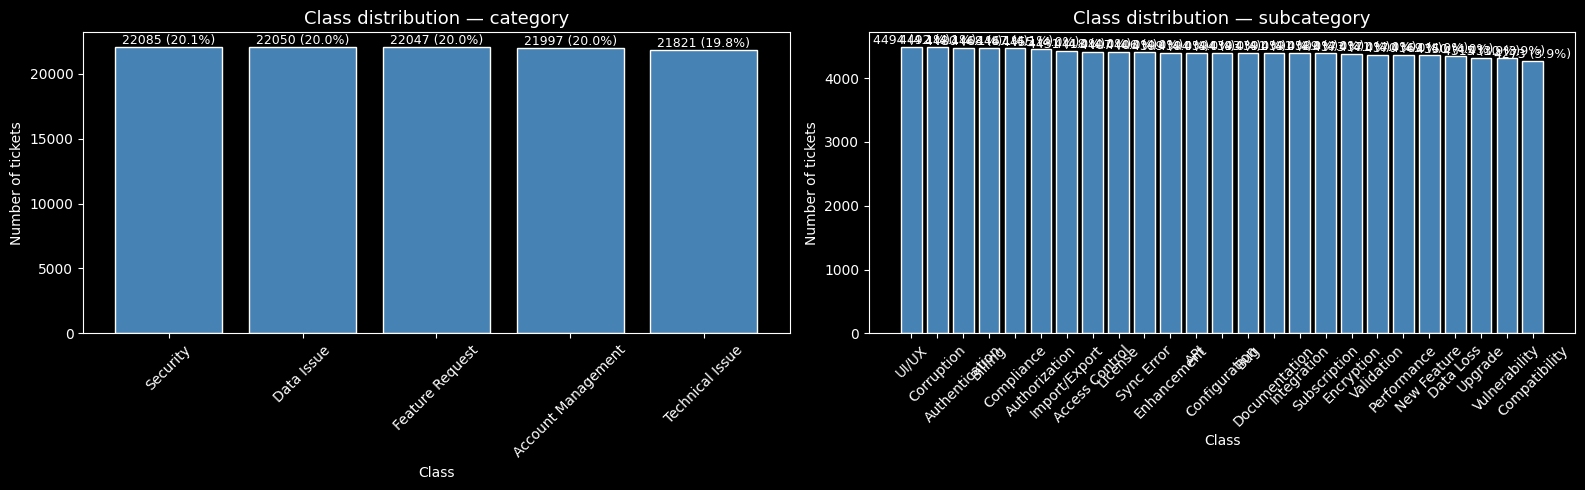


📊 IMBALANCE SUMMARY

  CATEGORY
    Security                  22085 tickets   20.1%  ██████████
    Data Issue                22050 tickets   20.0%  ██████████
    Feature Request           22047 tickets   20.0%  ██████████
    Account Management        21997 tickets   20.0%  ██████████
    Technical Issue           21821 tickets   19.8%  █████████

    ⚠️  Imbalance ratio: 1.0x  (largest / smallest class)
    🟢 Imbalance looks manageable

  SUBCATEGORY
    UI/UX                      4494 tickets    4.1%  ██
    Corruption                 4492 tickets    4.1%  ██
    Authentication             4480 tickets    4.1%  ██
    Billing                    4468 tickets    4.1%  ██
    Compliance                 4467 tickets    4.1%  ██
    Authorization              4455 tickets    4.0%  ██
    Import/Export              4431 tickets    4.0%  ██
    Access Control             4418 tickets    4.0%  ██
    License                    4407 tickets    4.0%  ██
    Sync Error                 4406 t

In [7]:
plot_class_distribution(y, target_encoders)

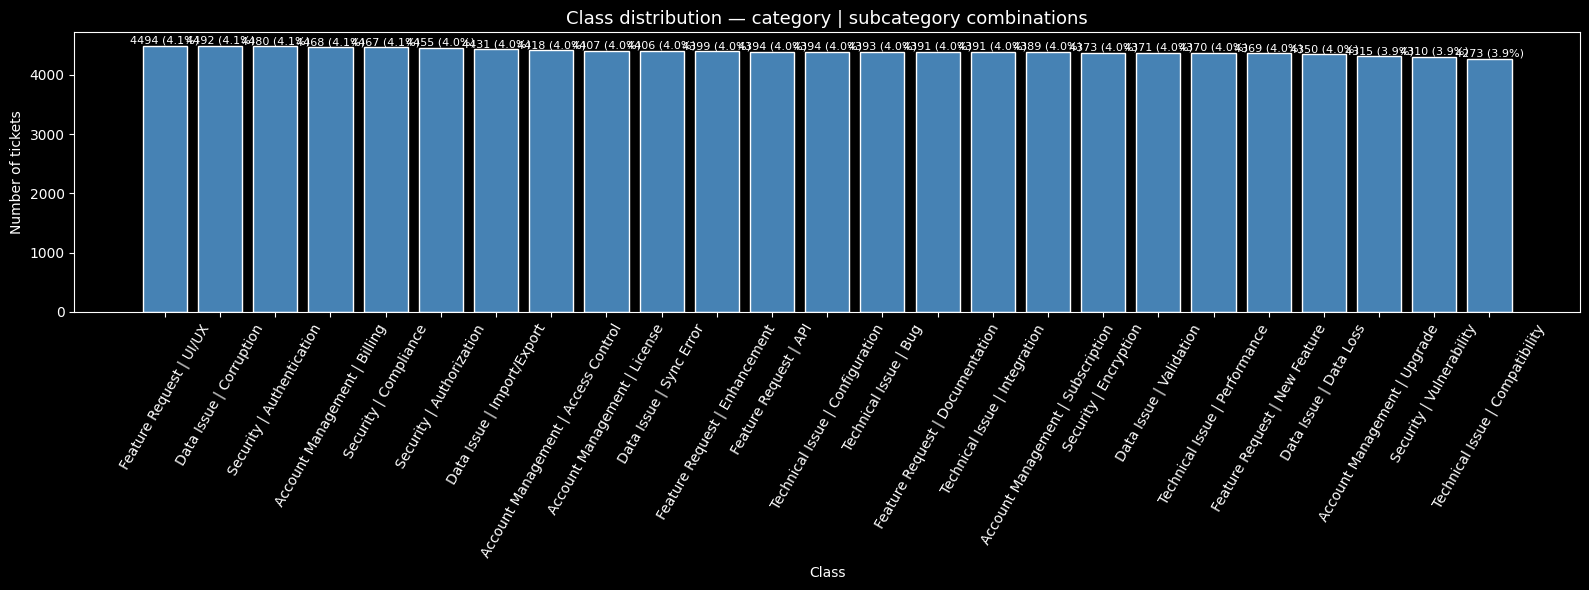


📊 COMBINED CLASS IMBALANCE SUMMARY

  Feature Request | UI/UX                   4494 tickets    4.1%  ██
  Data Issue | Corruption                   4492 tickets    4.1%  ██
  Security | Authentication                 4480 tickets    4.1%  ██
  Account Management | Billing              4468 tickets    4.1%  ██
  Security | Compliance                     4467 tickets    4.1%  ██
  Security | Authorization                  4455 tickets    4.0%  ██
  Data Issue | Import/Export                4431 tickets    4.0%  ██
  Account Management | Access Control       4418 tickets    4.0%  ██
  Account Management | License              4407 tickets    4.0%  ██
  Data Issue | Sync Error                   4406 tickets    4.0%  ██
  Feature Request | Enhancement             4399 tickets    4.0%  ██
  Feature Request | API                     4394 tickets    4.0%  ██
  Technical Issue | Configuration           4394 tickets    4.0%  ██
  Technical Issue | Bug                     4393 tickets    4.0%  

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# ── assumes you have already run the preprocessing pipeline ──
# X, y, feature_encoders, target_encoders = preprocess(df)

# ============================================================
# CLASS IMBALANCE ANALYSIS  COMBINED CATEGORY + SUBCATEGORY
# ============================================================
# For model 2 (subcategory predictor), what matters is the
# distribution of category+subcategory COMBINATIONS, since
# subcategory labels are only meaningful within their category.
# e.g. "Bug | Authentication" is a different class than
#      "Feature Request | Authentication"
# ============================================================

def plot_combined_class_distribution(y, target_encoders):

    # --- decode both columns back to readable strings ---
    decoded_category = y["category"].map(
        lambda i: target_encoders["category"].classes_[i]
    )
    decoded_subcategory = y["subcategory"].map(
        lambda i: target_encoders["subcategory"].classes_[i]
    )

    # --- create the combined label e.g. "Bug | Authentication" ---
    combined = decoded_category + " | " + decoded_subcategory

    # --- count occurrences of each combination ---
    counts = combined.value_counts().sort_values(ascending=False)
    percentages = (counts / counts.sum() * 100).round(1)

    # ── bar chart ──
    fig, ax = plt.subplots(figsize=(16, 6))

    bars = ax.bar(counts.index, counts.values, color="steelblue", edgecolor="white")
    ax.set_title("Class distribution  category | subcategory combinations", fontsize=13)
    ax.set_xlabel("Class")
    ax.set_ylabel("Number of tickets")
    ax.tick_params(axis="x", rotation=60)

    # annotate each bar with count and percentage
    for bar, pct in zip(bars, percentages):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{int(bar.get_height())} ({pct}%)",
            ha="center", va="bottom", fontsize=8
        )

    plt.tight_layout()
    plt.show()

    # ── print summary table ──
    print("\n📊 COMBINED CLASS IMBALANCE SUMMARY\n")
    for label, cnt, pct in zip(counts.index, counts.values, percentages.values):
        bar = "█" * int(pct // 2)
        print(f"  {label:<40} {cnt:>5} tickets  {pct:>5}%  {bar}")

    # ── imbalance ratio ──
    ratio = counts.max() / counts.min()
    print(f"\n  ⚠️  Imbalance ratio: {ratio:.1f}x  (largest / smallest combination)")
    print(f"  {'🔴 High imbalance  consider resampling or class weights' if ratio > 5 else '🟢 Imbalance looks manageable'}\n")

    # ── also flag combinations with very few samples ──
    # combinations with less than 30 samples are risky
    # the model won't have enough examples to learn from
    rare = counts[counts < 30]
    if not rare.empty:
        print(f"  🔴 {len(rare)} rare combinations (< 30 samples)  model may struggle with these:")
        for label, cnt in rare.items():
            print(f"     {label:<40} {cnt} samples")
    else:
        print("  🟢 No rare combinations found")


plot_combined_class_distribution(y, target_encoders)